# 公式テスト t3 — Reversible（可逆結合 A + B ⇌ C）

> **出典（E-Cell4 公式）**: Tests / Reversible — https://ecell4.e-cell.org/tests/Reversible.html
>
> 可逆な二分子結合。巨視的速度(kon/koff)と微視的速度(ka/kd)を各ソルバで比較するテスト。ここでは ODE と Gillespie を実行。

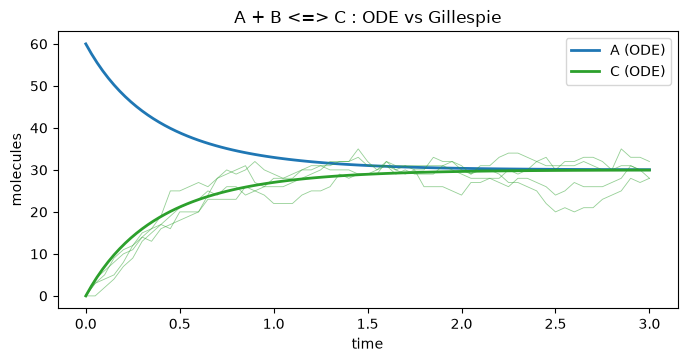

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

D, radius, N_A, U, ka_factor = 1, 0.005, 60, 0.5, 0.1
kD = 4 * np.pi * (radius * 2) * (D * 2)
ka = kD * ka_factor
kd = ka * N_A * U * U / (1 - U)
kon = ka * kD / (ka + kD)
koff = kd * kon / ka
duration = 3
with species_attributes():
    A | B | C | {'radius': radius, 'D': D}
with reaction_rules():
    A + B == C | (kon, koff)
m = get_model()

a = run_simulation(duration, y0={'A': N_A, 'B': N_A}, model=m, species_list=['A','B','C']).as_array()
plt.figure(figsize=(8,3.6))
plt.plot(a[:,0], a[:,1], 'C0-', lw=2, label='A (ODE)'); plt.plot(a[:,0], a[:,3], 'C2-', lw=2, label='C (ODE)')
for seed in range(4):
    g = run_simulation(duration, y0={'A': N_A, 'B': N_A}, model=m, solver='gillespie', ndiv=60, species_list=['A','B','C'], rndseed=seed).as_array()
    plt.plot(g[:,0], g[:,3], 'C2', lw=.6, alpha=.5)
plt.xlabel('time'); plt.ylabel('molecules'); plt.legend(); plt.title('A + B <=> C : ODE vs Gillespie'); plt.show()

## 全ソルバ比較（公式コード・参照）

```python
# 巨視的 -> ODE / Gillespie / meso
with reaction_rules(): A + B == C | (kon, koff)
# 微視的 -> spatiocyte / egfrd
with reaction_rules(): A + B == C | (ka, kd)
ret2 = ensemble_simulations(duration, ndiv=20, y0=y0, model=m, solver=('meso', Integer3(4,4,4)), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0=y0, model=m, solver=('spatiocyte', radius), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0=y0, model=m, solver=('egfrd', Integer3(4,4,4)), repeat=20)
```

**要点**: 反応が拡散に律速されない領域（本テスト, ka_factor=0.1）では、全ソルバが同じ平衡に一致する。
拡散律速の領域は次の t4 で扱う。